# UGA Grad Survivor — Monte Carlo Simulation
Reproduces all game mechanics (stats, perks, passive drains, milestones, card pools) and runs thousands of games to analyze balance across archetype × PI combinations.

In [1]:
import random
import math
import copy
from collections import defaultdict, Counter
import pandas as pd
import numpy as np

# Try optional viz libs
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style='whitegrid')
    HAS_PLT = True
except ImportError:
    HAS_PLT = False

## 1. Game Data

In [2]:
# ── Parse game data directly from JS source files ──
import re, json, os

JS_DATA_DIR = os.path.join(os.path.dirname(os.path.abspath('.')), 'js', 'data')
# If running from simulation/ folder, go up one level
if not os.path.isdir(JS_DATA_DIR):
    JS_DATA_DIR = os.path.join('..', 'js', 'data')

def parse_js_object(js_text):
    """Convert a JS object/array literal to Python via JSON.
    Handles: single quotes, trailing commas, unquoted keys, template literals, JS expressions."""
    s = js_text
    # Remove single-line comments (but not inside strings)
    s = re.sub(r'//.*?$', '', s, flags=re.MULTILINE)
    # Remove multi-line comments
    s = re.sub(r'/\*.*?\*/', '', s, flags=re.DOTALL)
    # Replace single-quoted strings with double-quoted
    # Simple approach: swap quotes (handle escaped quotes)
    result = []
    in_string = False
    string_char = None
    i = 0
    while i < len(s):
        c = s[i]
        if not in_string:
            if c in ('"', "'"):
                in_string = True
                string_char = c
                result.append('"')
            else:
                result.append(c)
        else:
            if c == '\\' and i + 1 < len(s):
                next_c = s[i+1]
                if string_char == "'" and next_c == "'":
                    result.append("'")
                    i += 2
                    continue
                elif string_char == "'" and next_c == '"':
                    result.append('\\"')
                    i += 2
                    continue
                else:
                    result.append(c)
                    result.append(next_c)
                    i += 2
                    continue
            elif c == string_char:
                in_string = False
                result.append('"')
            elif c == '"' and string_char == "'":
                result.append('\\"')
            else:
                result.append(c)
        i += 1
    s = ''.join(result)
    # Unquoted keys: word characters before a colon
    s = re.sub(r'(?<=[{,\n])\s*([a-zA-Z_]\w*)\s*:', r' "\1":', s)
    # Handle +number (JSON doesn't allow leading +)
    s = re.sub(r':\s*\+(\d)', r': \1', s)
    # Trailing commas before } or ]
    s = re.sub(r',\s*([}\]])', r'\1', s)
    # Replace JS true/false/null
    s = s.replace('true', 'true').replace('false', 'false').replace('null', 'null')
    # Handle Math.floor etc — shouldn't appear in data files but just in case
    s = re.sub(r'Math\.\w+\([^)]*\)', '0', s)
    return json.loads(s)

def load_js_array(filepath, var_name):
    """Load a JS file that defines `const VAR_NAME = [...]`."""
    with open(filepath, 'r') as f:
        text = f.read()
    # Find the array assignment
    pattern = rf'(?:const|let|var)\s+{var_name}\s*=\s*(\[[\s\S]*?\]);'
    m = re.search(pattern, text)
    if not m:
        raise ValueError(f"Could not find {var_name} in {filepath}")
    return parse_js_object(m.group(1))

def load_js_dict(filepath, var_name):
    """Load a JS file that defines `const VAR_NAME = {...}`."""
    with open(filepath, 'r') as f:
        text = f.read()
    pattern = rf'(?:const|let|var)\s+{var_name}\s*=\s*(\{{[\s\S]*?\}});'
    m = re.search(pattern, text)
    if not m:
        raise ValueError(f"Could not find {var_name} in {filepath}")
    return parse_js_object(m.group(1))

# ── Load archetypes ──
ARCHETYPE_DATA = load_js_dict(os.path.join(JS_DATA_DIR, 'archetypes.js'), 'ARCHETYPE_DATA')
print(f"Archetypes ({len(ARCHETYPE_DATA)}):")
for name, data in ARCHETYPE_DATA.items():
    st = data['st']
    print(f"  {name:20s}: M={st['mind']:2d} B={st['body']:2d} W={st['wallet']:2d} Bo={st['bonds']:2d} R={st['research']:2d}")

# ── Load PI data ──
PI_DATA = load_js_dict(os.path.join(JS_DATA_DIR, 'pi-data.js'), 'PI_DATA')
PI_TYPES = list(PI_DATA.keys())
print(f"\nPI Types ({len(PI_TYPES)}): {PI_TYPES}")

Archetypes (8):
  overachiever        : M=50 B=45 W=60 Bo=50 R=55
  vibe_coder          : M=55 B=40 W=60 Bo=45 R=60
  fun_haver           : M=40 B=55 W=50 Bo=70 R=35
  global_student      : M=50 B=50 W=60 Bo=55 R=50
  biologist           : M=45 B=50 W=55 Bo=60 R=40
  double_agent        : M=50 B=45 W=55 Bo=50 R=55
  gym_bro             : M=40 B=70 W=35 Bo=55 R=45
  neurodivergent      : M=55 B=45 W=50 Bo=50 R=50

PI Types (6): ['micromanager', 'ghost', 'exploiter', 'mentor', 'new_pi', 'dynasty']


In [3]:
# ── Load all card pools from JS files ──

PHASE1_CARDS = load_js_array(os.path.join(JS_DATA_DIR, 'cards-phase1.js'), 'PHASE1_CARDS')
PHASE2_CARDS = load_js_array(os.path.join(JS_DATA_DIR, 'cards-phase2.js'), 'PHASE2_CARDS')
PHASE3_CARDS = load_js_array(os.path.join(JS_DATA_DIR, 'cards-phase3.js'), 'PHASE3_CARDS')
UNIVERSAL_CARDS = load_js_array(os.path.join(JS_DATA_DIR, 'cards-universal.js'), 'UNIVERSAL_CARDS')
CALLBACK_CARDS = load_js_array(os.path.join(JS_DATA_DIR, 'cards-callback.js'), 'CALLBACK_CARDS')
MILESTONE_CARDS = load_js_array(os.path.join(JS_DATA_DIR, 'cards-milestone.js'), 'MILESTONE_CARDS')

# Exclusive cards file has two arrays
exclusive_path = os.path.join(JS_DATA_DIR, 'cards-exclusive.js')
EXCLUSIVE_CARDS = load_js_array(exclusive_path, 'EXCLUSIVE_CARDS')
PI_EXCLUSIVE_CARDS = load_js_array(exclusive_path, 'PI_EXCLUSIVE_CARDS')

all_pools = {
    'PHASE1': PHASE1_CARDS, 'PHASE2': PHASE2_CARDS, 'PHASE3': PHASE3_CARDS,
    'UNIVERSAL': UNIVERSAL_CARDS, 'CALLBACK': CALLBACK_CARDS,
    'MILESTONE': MILESTONE_CARDS, 'EXCLUSIVE': EXCLUSIVE_CARDS,
    'PI_EXCLUSIVE': PI_EXCLUSIVE_CARDS,
}

print("Card pools loaded from JS files:")
total = 0
for name, pool in all_pools.items():
    print(f"  {name:15s}: {len(pool):3d} cards")
    total += len(pool)
print(f"  {'TOTAL':15s}: {total:3d} cards")

Card pools loaded from JS files:
  PHASE1         :  19 cards
  PHASE2         :  99 cards
  PHASE3         :  22 cards
  UNIVERSAL      :  32 cards
  CALLBACK       :   6 cards
  MILESTONE      :   6 cards
  EXCLUSIVE      :  24 cards
  PI_EXCLUSIVE   :  18 cards
  TOTAL          : 226 cards


## 2. Game Engine

In [4]:
def get_phase(semester):
    if semester <= 2: return 1
    if semester <= 6: return 2
    return 3

def apply_perk(arch, stat, delta, tag, bonds):
    """Archetype perk modifier — mirrors applyPerk() in engine.js."""
    tech_tags = ['Pipeline Failure', 'Pipeline']
    social_tags = ['Social', 'Human Existence', 'Athens Life', 'Social Drama', 'Lab Drama']
    if arch == 'vibe_coder':
        if tag in tech_tags and delta > 0: return math.floor(delta * 1.5)
        if tag in social_tags and delta < 0: return math.floor(delta * 1.5)
    elif arch == 'fun_haver':
        if stat == 'bonds' and delta > 0: return math.floor(delta * 1.5)
        if stat == 'mind' and delta < 0: return math.floor(delta * 1.3)
        if stat == 'research' and delta > 0: return math.ceil(delta / 2)
    elif arch == 'global_student':
        if stat == 'bonds' and delta < 0: return math.ceil(delta / 2)
    elif arch == 'biologist':
        if stat == 'research' and delta < 0 and tag in tech_tags:
            if bonds > 50: return math.ceil(delta / 2)
            if bonds < 30: return math.floor(delta * 2)
        if stat == 'research' and delta > 0 and tag in ('Lab Life', 'Lab Politics'):
            return math.floor(delta * 1.3)
    elif arch == 'double_agent':
        if stat == 'research' and delta > 0: return delta + 3
    elif arch == 'gym_bro':
        if stat == 'wallet' and delta < 0: return math.floor(delta * 1.3)
        if stat == 'mind' and delta < 0: return math.floor(delta * 1.3)
    elif arch == 'neurodivergent':
        if stat == 'mind': return math.floor(delta * 1.5)
        if stat == 'research': return math.floor(delta * 1.3)
    return delta

def apply_pi_perk(pi_type, stat, delta, tag):
    """PI perk modifier — mirrors applyPIPerk() in engine.js."""
    is_advisor = (tag == 'Advisor')
    if pi_type == 'micromanager':
        if stat == 'research' and delta > 0: return math.floor(delta * 1.2)
        if stat == 'mind' and delta < 0 and is_advisor: return math.floor(delta * 1.3)
    elif pi_type == 'ghost':
        if stat == 'research' and delta > 0: return math.floor(delta * 0.8)
    elif pi_type == 'exploiter':
        if stat == 'research' and delta > 0: return math.floor(delta * 1.3)
        if stat == 'wallet' and delta < 0: return math.floor(delta * 1.3)
        if stat == 'bonds' and delta < 0 and is_advisor: return math.floor(delta * 1.3)
    elif pi_type == 'mentor':
        if delta < 0 and is_advisor: return min(delta + 3, 0)
        if stat == 'bonds' and delta > 0 and is_advisor: return math.floor(delta * 1.2)
        if stat == 'research' and delta > 0: return min(delta, 10)
    elif pi_type == 'new_pi':
        if stat == 'research' and delta > 0: return math.floor(delta * 1.25)
        if stat == 'mind' and delta < 0: return math.floor(delta * 1.2)
    elif pi_type == 'dynasty':
        if stat == 'wallet' and delta > 0: return math.floor(delta * 1.2)
        if stat == 'bonds' and delta < 0: return math.floor(delta * 1.3)
    return delta

In [5]:
STRATEGIES = {
    'random':     lambda card, gs: random.choice(['left','right']),
    'left_bias':  lambda card, gs: 'left' if random.random() < 0.65 else 'right',
    'right_bias': lambda card, gs: 'right' if random.random() < 0.65 else 'left',
    'greedy_mind': lambda card, gs: _greedy_pick(card, gs, 'mind'),
    'greedy_research': lambda card, gs: _greedy_pick(card, gs, 'research'),
    'balanced':   lambda card, gs: _balanced_pick(card, gs),
}

def _sum_effects(effects):
    if not effects: return 0
    return sum(v for k, v in effects.items() if k != 'network')

def _greedy_pick(card, gs, target_stat):
    eL = card['eL'] or {}
    eR = card['eR'] or {}
    lv = eL.get(target_stat, 0)
    rv = eR.get(target_stat, 0)
    if lv > rv: return 'left'
    if rv > lv: return 'right'
    return 'left' if _sum_effects(eL) >= _sum_effects(eR) else 'right'

def _balanced_pick(card, gs):
    """Pick the side that helps the weakest stat most."""
    weakest = min(gs['st'], key=gs['st'].get)
    eL = card['eL'] or {}
    eR = card['eR'] or {}
    lv = eL.get(weakest, 0)
    rv = eR.get(weakest, 0)
    if lv > rv: return 'left'
    if rv > lv: return 'right'
    return 'left' if _sum_effects(eL) >= _sum_effects(eR) else 'right'

In [6]:
def simulate_game(archetype, pi_type, strategy='random', rng=None):
    """Run one full game. Mirrors engine.js logic faithfully."""
    if rng is None: rng = random.Random()
    st = dict(ARCHETYPE_DATA[archetype]['st'])
    semester = 1; card_count = 0; total_cards = 0; network = 0; quals_attempts = 0
    memory = set()
    strategy_fn = STRATEGIES[strategy] if isinstance(strategy, str) else strategy

    def get_milestone(sem):
        for m in MILESTONE_CARDS:
            if m.get('semester') == sem: return m
        return None

    next_milestone = get_milestone(semester)

    def draw_card():
        nonlocal next_milestone, card_count, semester
        phase = get_phase(semester)
        if card_count >= 3 and next_milestone:
            ms = next_milestone; next_milestone = None
            if ms.get('piSelection'): return 'PI_SELECTION'
            if ms['id'] == 'ms_committee_1' and st['research'] < 25: st['mind'] = max(0, st['mind'] - 10)
            if ms['id'] == 'ms_committee_2' and st['research'] < 35: st['mind'] = max(0, st['mind'] - 15)
            return ms
        if card_count >= 3 and not next_milestone: card_count = 0
        if phase == 1: pool = list(PHASE1_CARDS)
        elif phase == 2: pool = list(PHASE2_CARDS)
        else: pool = list(PHASE3_CARDS)
        pool.extend(UNIVERSAL_CARDS)
        sem = semester
        pool = [cd for cd in pool
                if (cd.get('minSem') is None or sem >= cd['minSem'])
                and (cd.get('maxSem') is None or sem <= cd['maxSem'])
                and cd['id'] not in memory]
        for cb in CALLBACK_CARDS:
            if cb['id'] in memory: continue
            reqs = cb.get('requires', [])
            if reqs and all(r in memory for r in reqs): pool.append(cb)
        for ec in EXCLUSIVE_CARDS:
            if ec.get('exclusive') != archetype or ec['id'] in memory: continue
            if ec.get('minSem') is not None and sem < ec['minSem']: continue
            if ec.get('maxSem') is not None and sem > ec['maxSem']: continue
            pool.append(ec); pool.append(ec)
        if pi_type:
            for pc in PI_EXCLUSIVE_CARDS:
                if pc.get('exclusive') != pi_type or pc['id'] in memory: continue
                if pc.get('minSem') is not None and sem < pc['minSem']: continue
                if pc.get('maxSem') is not None and sem > pc['maxSem']: continue
                pool.append(pc); pool.append(pc)
        if not pool: pool = [c for c in UNIVERSAL_CARDS if c['id'] not in memory]
        if not pool: return None
        return rng.choice(pool)

    gs = {'st': st, 'archetype': archetype, 'pi_type': pi_type}

    for turn in range(200):
        card = draw_card()
        if card is None:
            return {'ending': 'defended', 'semester': semester, 'total_cards': total_cards, 'st': st, 'network': network, 'quals_attempts': quals_attempts}
        if card == 'PI_SELECTION':
            card_count = 0; semester += 1; next_milestone = get_milestone(semester)
            total_cards += 1; card_count += 1; continue
        tag = card.get('tag', '')
        side = strategy_fn(card, gs)
        effects = card.get('eL') if side == 'left' else card.get('eR')
        # Quals
        if card['id'] == 'ms_quals':
            thresh = 30 if archetype == 'biologist' else 25
            if st['research'] < thresh:
                quals_attempts += 1
                if quals_attempts >= 3:
                    return {'ending': 'mastered_out', 'semester': semester, 'total_cards': total_cards, 'st': st, 'network': network, 'quals_attempts': quals_attempts, 'cause': 'Failed Quals'}
                st['mind'] = max(0, st['mind'] - 15)
                memory.add('quals_retry_' + str(quals_attempts))
                card_count += 1; total_cards += 1; semester += 1
                next_milestone = next((c for c in MILESTONE_CARDS if c['id'] == 'ms_quals'), None)
                continue
        # Defense delay
        if card.get('milestone') and side == 'right' and card['id'] == 'ms_defense_sched':
            if 'defense_delayed' in memory:
                return {'ending': 'mastered_out', 'semester': semester, 'total_cards': total_cards, 'st': st, 'network': network, 'quals_attempts': quals_attempts, 'cause': 'Delayed Too Long'}
            memory.add('defense_delayed')
        # Defense research gate
        if card['id'] == 'ms_defense' and st['research'] < 30:
            return {'ending': 'mastered_out', 'semester': semester, 'total_cards': total_cards, 'st': st, 'network': network, 'quals_attempts': quals_attempts, 'cause': 'Insufficient Research'}
        # Apply effects
        if effects:
            for stat_key, delta in effects.items():
                if stat_key == 'network': network = max(0, network + delta); continue
                modified = apply_perk(archetype, stat_key, delta, tag, st.get('bonds', 50))
                if pi_type: modified = apply_pi_perk(pi_type, stat_key, modified, tag)
                st[stat_key] = max(0, min(100, st[stat_key] + modified))
        # Post-choice archetype effects (NERFED: overachiever triggers every 3 cards, +3 instead of +5)
        if archetype == 'overachiever' and total_cards % 3 == 0:
            weak = [s for s in ['mind', 'body', 'wallet', 'bonds'] if st[s] < 20]
            if weak:
                pick = rng.choice(weak)
                st[pick] = min(100, st[pick] + 3)
        if archetype == 'gym_bro' and st['body'] < 25: st['body'] = 25
        if archetype == 'double_agent':
            drain = rng.choice(['mind', 'body', 'wallet', 'bonds'])
            st[drain] = max(0, st[drain] - 2)
        # Passive drains
        if st['wallet'] < 5: st['wallet'] = 5
        if st['wallet'] < 20: st['mind'] = max(0, st['mind'] - 3); st['body'] = max(0, st['body'] - 2)
        if st['bonds'] < 20: st['mind'] = max(0, st['mind'] - 2); st['body'] = max(0, st['body'] - 1)
        if st['research'] < 20 and semester >= 3: st['mind'] = max(0, st['mind'] - 2)
        if st['research'] < 15 and semester >= 5: st['bonds'] = max(0, st['bonds'] - 2)
        if archetype == 'global_student' and semester >= 8: st['mind'] = max(0, st['mind'] - 3)
        # Record memory
        if card.get('sets'):
            for flag in card['sets']: memory.add(flag)
        memory.add(card['id'])
        total_cards += 1; card_count += 1
        # Check endings
        if st['wallet'] <= 0: return {'ending': 'broke', 'semester': semester, 'total_cards': total_cards, 'st': st, 'network': network, 'quals_attempts': quals_attempts, 'cause': 'Wallet'}
        if st['body'] <= 0: return {'ending': 'hospitalized', 'semester': semester, 'total_cards': total_cards, 'st': st, 'network': network, 'quals_attempts': quals_attempts, 'cause': 'Body'}
        if st['mind'] <= 0: return {'ending': 'burnt_out', 'semester': semester, 'total_cards': total_cards, 'st': st, 'network': network, 'quals_attempts': quals_attempts, 'cause': 'Mind'}
        if st['bonds'] <= 0: return {'ending': 'disappeared', 'semester': semester, 'total_cards': total_cards, 'st': st, 'network': network, 'quals_attempts': quals_attempts, 'cause': 'Bonds'}
        if 'defended' in memory: return {'ending': 'defended', 'semester': semester, 'total_cards': total_cards, 'st': st, 'network': network, 'quals_attempts': quals_attempts}
        if semester > 10: return {'ending': 'mastered_out', 'semester': semester, 'total_cards': total_cards, 'st': st, 'network': network, 'quals_attempts': quals_attempts, 'cause': 'Time'}
        if card_count >= 3 and not next_milestone: semester += 1; next_milestone = get_milestone(semester)
    return {'ending': 'stuck', 'semester': semester, 'total_cards': total_cards, 'st': st, 'network': network, 'quals_attempts': quals_attempts}

# Quick test
r = simulate_game('overachiever', 'mentor', 'random', rng=random.Random(42))
print(f"Test: {r['ending']} at sem {r['semester']} ({r['total_cards']} cards)")
print(f"  Stats: M={r['st']['mind']} B={r['st']['body']} W={r['st']['wallet']} Bo={r['st']['bonds']} R={r['st']['research']}")

Test: hospitalized at sem 7 (15 cards)
  Stats: M=30 B=0 W=37 Bo=90 R=95


## 3. Run Simulations

In [7]:
N_RUNS = 2000  # per combo
STRATEGY = 'random'

archetypes = list(ARCHETYPE_DATA.keys())
pi_types = PI_TYPES

results = []
for arch in archetypes:
    for pi in pi_types:
        for i in range(N_RUNS):
            r = simulate_game(arch, pi, STRATEGY)
            r['archetype'] = arch
            r['pi_type'] = pi
            r['run'] = i
            results.append(r)

df = pd.DataFrame(results)
df['defended'] = (df['ending'] == 'defended').astype(int)
print(f"Total runs: {len(df)}")
df['ending'].value_counts()

Total runs: 96000


ending
defended        55226
burnt_out       24859
hospitalized    10462
mastered_out     3298
disappeared      2155
Name: count, dtype: int64

## 4. Overall Ending Distribution

=== Overall Ending Distribution (%) ===
ending
defended        57.5
burnt_out       25.9
hospitalized    10.9
mastered_out     3.4
disappeared      2.2



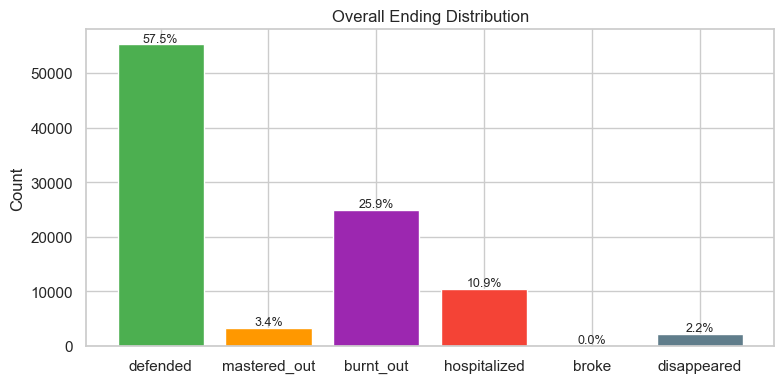

In [8]:
ending_pct = df['ending'].value_counts(normalize=True).mul(100).round(1)
print("=== Overall Ending Distribution (%) ===")
print(ending_pct.to_string())
print()

if HAS_PLT:
    fig, ax = plt.subplots(figsize=(8, 4))
    order = ['defended','mastered_out','burnt_out','hospitalized','broke','disappeared']
    colors = ['#4CAF50','#FF9800','#9C27B0','#F44336','#795548','#607D8B']
    counts = df['ending'].value_counts().reindex(order, fill_value=0)
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_title('Overall Ending Distribution')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + len(df)*0.005, f'{v/len(df)*100:.1f}%', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()

## 5. Defense Rate by Archetype × PI

=== Defense Rate (%) by Archetype × PI ===
pi_type         dynasty  exploiter  ghost  mentor  micromanager  new_pi   ALL
archetype                                                                    
biologist          65.0       64.7   70.5    78.0          66.2    57.6  67.0
double_agent       52.1       52.0   61.3    66.8          55.4    48.9  56.1
fun_haver          36.4       32.9   33.4    45.4          35.2    23.9  34.5
global_student     75.0       75.7   75.8    80.6          70.9    62.6  73.4
gym_bro            43.0       34.9   46.0    51.9          40.0    25.0  40.1
neurodivergent     52.6       51.3   57.8    63.8          54.7    41.7  53.7
overachiever       80.6       81.4   87.2    89.3          80.6    75.5  82.4
vibe_coder         51.0       49.6   60.0    62.2          52.3    42.6  53.0



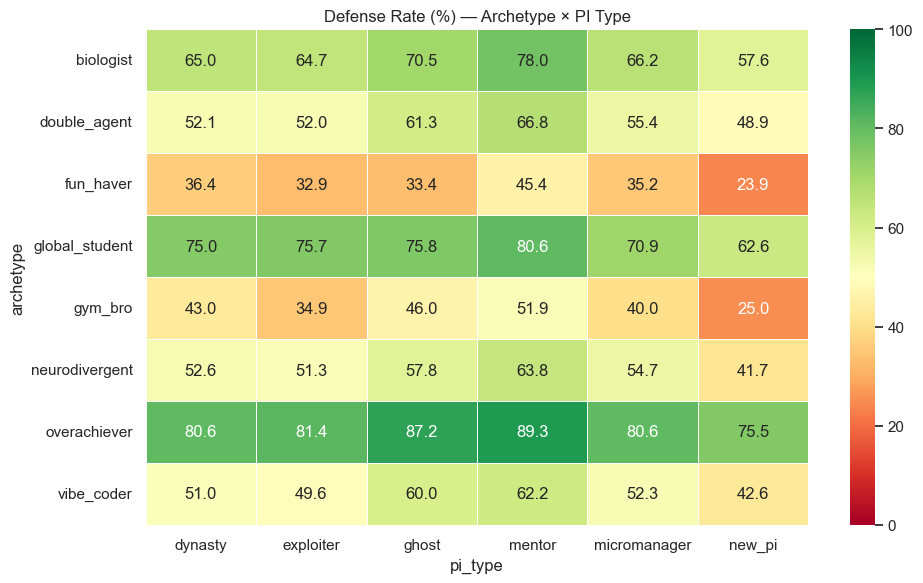

In [9]:
pivot = df.pivot_table(values='defended', index='archetype', columns='pi_type', aggfunc='mean').mul(100).round(1)
pivot['ALL'] = df.groupby('archetype')['defended'].mean().mul(100).round(1)

print("=== Defense Rate (%) by Archetype × PI ===")
print(pivot.to_string())
print()

if HAS_PLT:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(pivot.drop(columns='ALL'), annot=True, fmt='.1f', cmap='RdYlGn',
                vmin=0, vmax=100, ax=ax, linewidths=0.5)
    ax.set_title('Defense Rate (%) — Archetype × PI Type')
    plt.tight_layout()
    plt.show()

## 6. Ending Breakdown by Archetype

=== Ending % by Archetype ===
ending          defended  mastered_out  burnt_out  hospitalized  broke  disappeared
archetype                                                                          
biologist           67.0           3.0       20.8           8.0      0          1.2
double_agent        56.1           0.1       16.2          23.3      0          4.4
fun_haver           34.5          20.6       40.8           3.8      0          0.3
global_student      73.4           0.4       17.1           9.0      0          0.0
gym_bro             40.1           0.6       57.8           0.0      0          1.4
neurodivergent      53.7           2.2       28.8          12.5      0          2.9
overachiever        82.4           0.2        9.9           5.6      0          1.9
vibe_coder          53.0           0.4       15.7          25.1      0          5.9



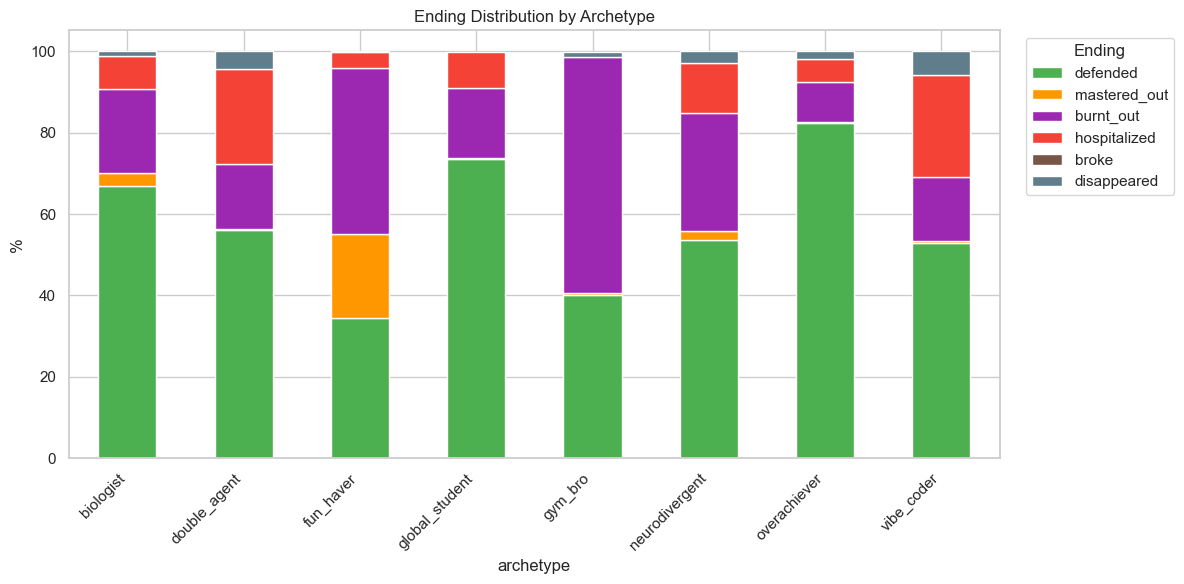

In [10]:
ending_by_arch = df.groupby(['archetype','ending']).size().unstack(fill_value=0)
ending_by_arch_pct = ending_by_arch.div(ending_by_arch.sum(axis=1), axis=0).mul(100).round(1)

order = ['defended','mastered_out','burnt_out','hospitalized','broke','disappeared']
ending_by_arch_pct = ending_by_arch_pct.reindex(columns=order, fill_value=0)

print("=== Ending % by Archetype ===")
print(ending_by_arch_pct.to_string())
print()

if HAS_PLT:
    fig, ax = plt.subplots(figsize=(12, 6))
    ending_by_arch_pct.plot(kind='bar', stacked=True, ax=ax,
                            color=['#4CAF50','#FF9800','#9C27B0','#F44336','#795548','#607D8B'])
    ax.set_title('Ending Distribution by Archetype')
    ax.set_ylabel('%')
    ax.legend(title='Ending', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 7. Ending Breakdown by PI Type

=== Ending % by PI Type ===
ending        defended  mastered_out  burnt_out  hospitalized  broke  disappeared
pi_type                                                                          
dynasty           57.0           3.8       23.1          10.6      0          5.6
exploiter         55.3           3.2       26.4          11.7      0          3.4
ghost             61.5           5.1       21.7          10.3      0          1.4
mentor            67.3           3.4       18.7          10.2      0          0.5
micromanager      56.9           2.8       26.9          11.8      0          1.7
new_pi            47.3           2.3       38.7          10.9      0          0.9



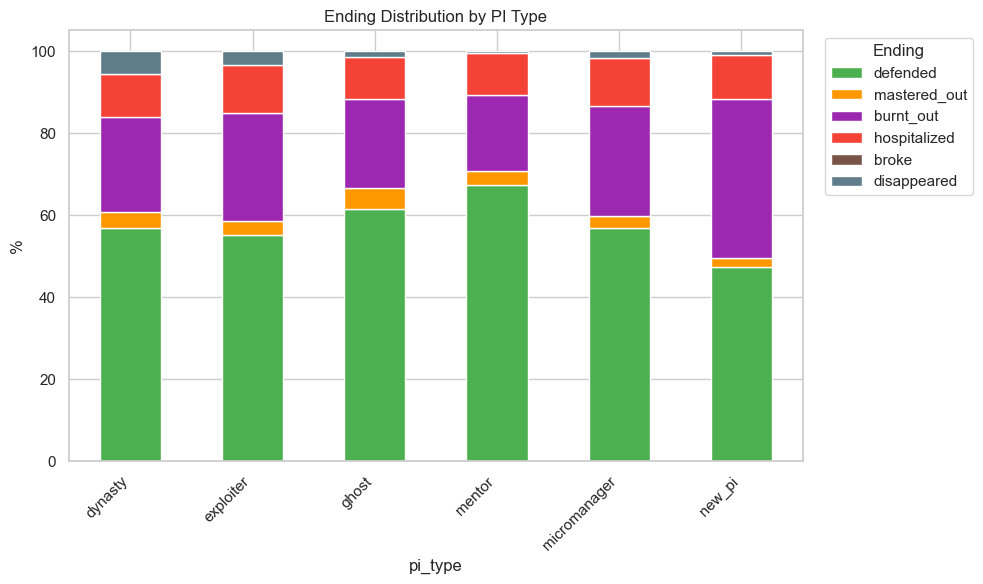

In [11]:
ending_by_pi = df.groupby(['pi_type','ending']).size().unstack(fill_value=0)
ending_by_pi_pct = ending_by_pi.div(ending_by_pi.sum(axis=1), axis=0).mul(100).round(1)
ending_by_pi_pct = ending_by_pi_pct.reindex(columns=order, fill_value=0)

print("=== Ending % by PI Type ===")
print(ending_by_pi_pct.to_string())
print()

if HAS_PLT:
    fig, ax = plt.subplots(figsize=(10, 6))
    ending_by_pi_pct.plot(kind='bar', stacked=True, ax=ax,
                          color=['#4CAF50','#FF9800','#9C27B0','#F44336','#795548','#607D8B'])
    ax.set_title('Ending Distribution by PI Type')
    ax.set_ylabel('%')
    ax.legend(title='Ending', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 8. Average Survival Semester (for non-defenders)

In [12]:
non_defended = df[df['ending'] != 'defended']

avg_sem_arch = non_defended.groupby('archetype')['semester'].mean().round(2)
avg_sem_pi = non_defended.groupby('pi_type')['semester'].mean().round(2)

print("=== Avg Death Semester by Archetype (non-defenders) ===")
print(avg_sem_arch.sort_values().to_string())
print()
print("=== Avg Death Semester by PI (non-defenders) ===")
print(avg_sem_pi.sort_values().to_string())

=== Avg Death Semester by Archetype (non-defenders) ===
archetype
vibe_coder        5.30
gym_bro           5.44
neurodivergent    5.65
double_agent      5.90
biologist         5.99
overachiever      6.00
global_student    6.36
fun_haver         6.37

=== Avg Death Semester by PI (non-defenders) ===
pi_type
new_pi          5.55
exploiter       5.75
micromanager    5.78
dynasty         5.87
mentor          6.12
ghost           6.14


## 9. Average Final Stats (all runs)

In [13]:
# Extract final stats into columns
for stat in ['mind','body','wallet','bonds','research']:
    df[f'final_{stat}'] = df['st'].apply(lambda x: x.get(stat, 0))

stat_cols = [f'final_{s}' for s in ['mind','body','wallet','bonds','research']]

print("=== Average Final Stats by Archetype ===")
print(df.groupby('archetype')[stat_cols].mean().round(1).to_string())
print()
print("=== Average Final Stats by PI ===")
print(df.groupby('pi_type')[stat_cols].mean().round(1).to_string())

=== Average Final Stats by Archetype ===
                final_mind  final_body  final_wallet  final_bonds  final_research
archetype                                                                        
biologist             50.7        33.8          50.9         81.7            63.5
double_agent          51.3        20.1          42.7         66.4            85.1
fun_haver             29.0        41.4          44.7         89.8            36.7
global_student        52.3        32.7          54.2         93.4            68.2
gym_bro               23.3        53.4          27.5         74.1            61.9
neurodivergent        51.3        30.0          45.1         71.3            70.0
overachiever          61.1        32.0          55.6         78.8            75.5
vibe_coder            54.1        21.3          53.2         65.7            75.9

=== Average Final Stats by PI ===
              final_mind  final_body  final_wallet  final_bonds  final_research
pi_type                 

## 10. Strategy Comparison

In [14]:
N_STRAT = 1000
strat_results = []

for strat_name in STRATEGIES:
    for i in range(N_STRAT):
        arch = random.choice(archetypes)
        pi = random.choice(pi_types)
        r = simulate_game(arch, pi, strat_name)
        strat_results.append({'strategy': strat_name, 'ending': r['ending'],
                              'semester': r['semester'], 'defended': int(r['ending']=='defended')})

sdf = pd.DataFrame(strat_results)

print("=== Defense Rate by Strategy ===")
print(sdf.groupby('strategy')['defended'].mean().mul(100).round(1).sort_values(ascending=False).to_string())
print()
print("=== Ending Distribution by Strategy ===")
strat_endings = sdf.groupby(['strategy','ending']).size().unstack(fill_value=0)
strat_endings_pct = strat_endings.div(strat_endings.sum(axis=1), axis=0).mul(100).round(1)
print(strat_endings_pct.to_string())

=== Defense Rate by Strategy ===
strategy
balanced           98.7
greedy_mind        83.9
greedy_research    71.2
right_bias         60.5
left_bias          57.8
random             56.6

=== Ending Distribution by Strategy ===
ending           burnt_out  defended  disappeared  hospitalized  mastered_out
strategy                                                                     
balanced               0.8      98.7          0.0           0.1           0.4
greedy_mind            0.1      83.9          1.8           3.7          10.5
greedy_research       18.3      71.2          1.3           9.2           0.0
left_bias             22.9      57.8          1.6          12.6           5.1
random                28.7      56.6          1.6           9.7           3.4
right_bias            26.6      60.5          3.0           7.1           2.8


## 11. Cause of Death Analysis

In [15]:
deaths = df[df['ending'] != 'defended'].copy()
death_cause = deaths['ending'].value_counts(normalize=True).mul(100).round(1)

print("=== Non-Defense Endings Distribution ===")
print(death_cause.to_string())
print()

# Which stat kills each archetype most?
print("=== Most Common Death per Archetype ===")
for arch in archetypes:
    sub = deaths[deaths['archetype'] == arch]
    if len(sub) == 0:
        print(f"  {arch}: no deaths!")
        continue
    top = sub['ending'].value_counts().head(3)
    top_str = ', '.join(f"{e} ({v/len(sub)*100:.0f}%)" for e, v in top.items())
    print(f"  {arch}: {top_str}")

=== Non-Defense Endings Distribution ===
ending
burnt_out       61.0
hospitalized    25.7
mastered_out     8.1
disappeared      5.3

=== Most Common Death per Archetype ===
  overachiever: burnt_out (56%), hospitalized (32%), disappeared (11%)
  vibe_coder: hospitalized (53%), burnt_out (33%), disappeared (12%)
  fun_haver: burnt_out (62%), mastered_out (31%), hospitalized (6%)
  global_student: burnt_out (65%), hospitalized (34%), mastered_out (2%)
  biologist: burnt_out (63%), hospitalized (24%), mastered_out (9%)
  double_agent: hospitalized (53%), burnt_out (37%), disappeared (10%)
  gym_bro: burnt_out (97%), disappeared (2%), mastered_out (1%)
  neurodivergent: burnt_out (62%), hospitalized (27%), disappeared (6%)


## 12. Balance Summary & Recommendations

In [16]:
print("="*60)
print("BALANCE SUMMARY")
print("="*60)

# Overall
overall_def = df['defended'].mean() * 100
print(f"\nOverall defense rate: {overall_def:.1f}%")
print(f"Target range: 15-35% (challenging but achievable)")
print()

# Best/worst combos
combo = df.groupby(['archetype','pi_type'])['defended'].mean().mul(100).round(1)
print(f"Easiest combo:  {combo.idxmax()} → {combo.max():.1f}%")
print(f"Hardest combo:  {combo.idxmin()} → {combo.min():.1f}%")
print(f"Spread:         {combo.max() - combo.min():.1f} pp")
print()

# Archetype ranking
arch_rate = df.groupby('archetype')['defended'].mean().mul(100).round(1).sort_values(ascending=False)
print("Archetype defense rates (high → low):")
for a, r in arch_rate.items():
    bar = '█' * int(r / 2)
    print(f"  {a:20s} {r:5.1f}% {bar}")

print()
pi_rate = df.groupby('pi_type')['defended'].mean().mul(100).round(1).sort_values(ascending=False)
print("PI defense rates (high → low):")
for p, r in pi_rate.items():
    bar = '█' * int(r / 2)
    print(f"  {p:20s} {r:5.1f}% {bar}")

print()
print("─" * 60)
print("FLAGS:")
if overall_def > 40:
    print("  ⚠️  Game may be too easy overall")
elif overall_def < 10:
    print("  ⚠️  Game may be too hard overall")
else:
    print("  ✅ Overall difficulty looks reasonable")

if combo.max() - combo.min() > 40:
    print("  ⚠️  Large spread between easiest/hardest combo (>40pp)")

for a, r in arch_rate.items():
    if r < 5: print(f"  ⚠️  {a} almost never defends ({r}%)")
    if r > 60: print(f"  ⚠️  {a} defends too easily ({r}%)")

for p, r in pi_rate.items():
    if r < 5: print(f"  ⚠️  {p} PI almost never allows defense ({r}%)")
    if r > 60: print(f"  ⚠️  {p} PI makes defense too easy ({r}%)")

BALANCE SUMMARY

Overall defense rate: 57.5%
Target range: 15-35% (challenging but achievable)

Easiest combo:  ('overachiever', 'mentor') → 89.3%
Hardest combo:  ('fun_haver', 'new_pi') → 23.9%
Spread:         65.4 pp

Archetype defense rates (high → low):
  overachiever          82.4% █████████████████████████████████████████
  global_student        73.4% ████████████████████████████████████
  biologist             67.0% █████████████████████████████████
  double_agent          56.1% ████████████████████████████
  neurodivergent        53.7% ██████████████████████████
  vibe_coder            53.0% ██████████████████████████
  gym_bro               40.1% ████████████████████
  fun_haver             34.5% █████████████████

PI defense rates (high → low):
  mentor                67.3% █████████████████████████████████
  ghost                 61.5% ██████████████████████████████
  dynasty               57.0% ████████████████████████████
  micromanager          56.9% █████████████████████